# Oregon Forest Fires 2020-2022

ссылка на датасет https://www.kaggle.com/datasets/wumanandpat/oregon-forest-fires-2020-2022/code

Шаг 1: Структура и состав датасета

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Загрузка датасета
file_path = "forest.csv"
df = pd.read_csv(file_path)

pd.set_option("display.max_columns", None)

# Проверяем первые строки датасета
df.head(5)

,Serial,FireCategory,FireYear,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,Protected_Acres,HumanOrLightning,CauseBy,GeneralCause,SpecificCause,Cause_Comments,Lat_DD,Long_DD,LatLongDD,FO_LandOwnType,Twn,Rng,Sec,Subdiv,LandmarkLocation,County,RegUseZone,RegUseRestriction,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber
0,102649,STAT,2015,EOA,Klamath-Lake,Klamath,15-981082-16,Bass 497,B,3.20,3.20,Human,Other-Public,Under Invest,NaN,NaN,42.13361,-122.04083,POINT (-122.04083 42.13361),Industrial,39S,7E,31.0,NWSE,Topsy Area,Klamath,KF1,Reg Use Closure,Does Not Apply - Eastern OR,09/02/2015 05:00:00 PM,09/02/2015 05:05:00 PM,09/02/2015 05:00:00 PM,09/02/2015 11:00:00 PM,09/05/2015 12:00:00 AM,10/13/2015 08:39:00 AM,98,981,082
1,131239,STAT,2022,EOA,Walker Range - WRFPA,Crescent,22-991220-23,Hay Fire,A,NaN,0.20,Human,NaN,Miscellaneous,NaN,NaN,43.59358,-121.49422,POINT (-121.49422 43.59358),Other Public,23S,10E,11.0,NWSE,Hwy 31,Klamath,WC2,NaN,NaN,NaN,08/16/2022 06:56:00 PM,NaN,NaN,08/18/2022 12:00:00 AM,08/18/2022 09:11:00 AM,99,991,220
2,58256,STAT,2000,EOA,Central Oregon,John Day,00-952011-01,Slick Ear #2,B,0.75,0.75,Lightning,Lightning,Lightning,Lightning,NaN,44.91519,-119.28863,POINT (-119.28863 44.91519),BLM,07S,29E,31.0,NESW,11 MI SE Ritter LO,Grant,EC2,Reg Use Closure,Does Not Apply - Eastern OR,07/18/2000 07:00:00 PM,07/19/2000 01:20:00 PM,07/19/2000 01:15:00 PM,07/20/2000 12:50:00 AM,07/20/2000 09:13:00 AM,11/14/2000 09:16:00 AM,95,952,011
3,59312,STAT,2000,EOA,Northeast Oregon,La Grande,00-971024-01,Woodley,C,80.00,80.00,Lightning,Lightning,Lightning,Lightning,NaN,45.08509,-118.33440,POINT (-118.3344 45.08509),Other Private,05S,36E,32.0,NESW,Woodley C.G,Union,NE3,Reg Use Closure,Does Not Apply - Eastern OR,08/24/2000 05:30:00 AM,08/24/2000 01:07:00 PM,08/24/2000 01:07:00 PM,09/01/2000 09:30:00 PM,08/29/2000 03:59:00 PM,12/21/2000 04:22:00 PM,97,971,024
4,61657,STAT,2001,SOA,Southwest Oregon,Grants Pass,01-712133-02,QUEENS BRANCH,A,0.10,0.10,Human,Motorist,Smoking,Other - Smoker Related,NaN,42.53671,-123.21215,POINT (-123.21215 42.53671),BLM,35S,04W,7.0,SESE,7 N ROGUE RIVER,Jackson,SW3,Reg Use Closure,Lvl 3 Restricted Shutdown,08/10/2001 05:40:00 PM,08/10/2001 05:47:00 PM,08/10/2001 05:45:00 PM,08/10/2001 06:30:00 PM,08/10/2001 06:42:00 PM,08/17/2001 11:45:00 AM,71,712,133


Размер: 23 490 записей, 38 столбцов.

Типы данных:

object — 29 столбцов (возможно, категориальные или даты).

float64 — 5 столбцов.

int64 — 4 столбца.

Пропуски:

Есть пропущенные значения, особенно в Cause_Comments (почти 60% пропущено), CauseBy, SpecificCause, координатах (Lat_DD, Long_DD) и датах (Ign_DateTime, Discover_DateTime, Control_DateTime).

Потенциальные признаки для анализа:

Временные (FireYear, Ign_DateTime и др.)

Географические (Lat_DD, Long_DD, County)

Причины пожаров (CauseBy, GeneralCause, SpecificCause)

Площадь пожара (EstTotalAcres, Protected_Acres)

In [ ]:
# Общая информация о датасете
df_info = df.info()
df_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Serial                  23490 non-null  int64  
 1   FireCategory            23490 non-null  object 
 2   FireYear                23490 non-null  int64  
 3   Area                    23490 non-null  object 
 4   DistrictName            23490 non-null  object 
 5   UnitName                23490 non-null  object 
 6   FullFireNumber          23490 non-null  object 
 7   FireName                23490 non-null  object 
 8   Size_class              23490 non-null  object 
 9   EstTotalAcres           23411 non-null  float64
 10  Protected_Acres         23490 non-null  float64
 11  HumanOrLightning        23490 non-null  object 
 12  CauseBy                 23362 non-null  object 
 13  GeneralCause            23490 non-null  object 
 14  SpecificCause           23266 non-null

Количество пропусков в каждой колонке

In [ ]:
df.isnull().sum()

,0
Serial,0
FireCategory,0
FireYear,0
Area,0
DistrictName,0
UnitName,0
FullFireNumber,0
FireName,0
Size_class,0
EstTotalAcres,79


**Переменные:**

Serial: Идентификатор, значения варьируются от 57485 до 134021.

FireYear: Средний год — 2010, диапазон от 2000 до 2022.

Size_class: 7 уникальных категорий, большая часть (16 013 записей) относится к классу "A".

EstTotalAcres и Protected_Acres: Площадь варьируется от 0 до почти 500 тыс. акров, среднее значение для "EstTotalAcres" — 270 акров, для "Protected_Acres" — 63 акра.

CauseBy и GeneralCause: Большинство причин связаны с "Lightning" (молния), 17 197 записей.

CauseBy:

Основная причина — молния (Lightning), что встречается в 62% записей. Это важная информация для анализа причин возникновения пожаров.

County:

Включает 23 уникальных значения, с самым частым значением "Jackson". Это дает представление о географическом распределении данных и может быть полезно для анализа по регионам.

DistrictName:

Содержит 14 уникальных значений, таких как "Southwest Oregon", "Grants Pass" и другие, что, вероятно, относится к административным районам. Это дает возможность анализировать, в каких районах чаще происходят пожары и какие факторы могут этому способствовать (например, тип местности или климат).

FO_LandOwnType:

Преобладает тип "Rural Residential" (сельские жилые зоны), что может быть связано с повышенной вероятностью возникновения пожаров в таких местах.

Географические данные:

Lat_DD и Long_DD: Широта и долгота имеют минимальные и максимальные значения, что указывает на разнообразие локаций.

Временные данные:

Ign_DateTime, ReportDateTime и другие: Пропуски в датах и времени, но в целом данные варьируются от 2000 года до текущего времени.

Пропуски:

Cause_Comments имеет 61% пропусков

Несколько столбцов (например, Subdiv, LandmarkLocation) имеют умеренные пропуски.

Аномалии:

Площадь пожаров варьируется очень сильно: от небольших значений (меньше 1 акра) до сотен тысяч акров.

In [ ]:
# Описательная статистика
df.describe(include='all')

,Serial,FireCategory,FireYear,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,Protected_Acres,HumanOrLightning,CauseBy,GeneralCause,SpecificCause,Cause_Comments,Lat_DD,Long_DD,LatLongDD,FO_LandOwnType,Twn,Rng,Sec,Subdiv,LandmarkLocation,County,RegUseZone,RegUseRestriction,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber
count,23490.000000,23490,23490.00000,23490,23490,23490,23490,23490,23490,23411.000000,23490.000000,23490,23362,23490,23266,9805,23480.000000,23480.000000,23480,23490,23478,23475,23478.000000,23459,22208,23490,23440,23401,23401,23396,23490,23396,23395,23487,23490,23490.000000,23490.000000,23490
unique,NaN,1,NaN,3,14,31,23335,19637,7,NaN,NaN,3,16,10,117,6876,NaN,NaN,23116,15,100,108,NaN,23,17126,37,144,6,7,20257,22822,22504,22304,11005,22865,NaN,NaN,1009
top,NaN,STAT,NaN,SOA,Southwest Oregon,Grants Pass,02-952017-03,Mill Creek,A,NaN,NaN,Human,Lightning,Lightning,Lightning,Lightning,NaN,NaN,POINT (-124.19892 43.65641),Rural Residential,36S,06W,NaN,SWNE,Roseburg,Jackson,SW3,Reg Use Closure,Does Not Apply - Eastern OR,07/15/2018 09:00:00 AM,08/17/2022 05:00:00 PM,08/17/2022 05:00:00 PM,12/31/2013 12:00:00 PM,08/19/2008 12:00:00 AM,10/26/2001 10:20:00 AM,NaN,NaN,018
freq,NaN,23490,NaN,12125,5975,3072,2,33,17013,NaN,NaN,17197,6250,6266,6247,381,NaN,NaN,9,5791,1272,973,NaN,1615,101,3338,3011,14671,6562,92,18,19,20,67,12,NaN,NaN,257
mean,90425.933461,NaN,2010.80132,NaN,NaN,NaN,NaN,NaN,NaN,270.802503,63.454008,NaN,NaN,NaN,NaN,NaN,43.718410,-122.258736,NaN,NaN,NaN,NaN,18.576753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.754662,779.371052,NaN
std,20901.016028,NaN,6.73508,NaN,NaN,NaN,NaN,NaN,NaN,6816.736966,1973.577812,NaN,NaN,NaN,NaN,NaN,1.226385,1.707589,NaN,NaN,NaN,NaN,10.439507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.618857,146.534574,NaN
min,57485.000000,NaN,2000.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,41.089460,-124.983610,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,511.000000,NaN
25%,72508.500000,NaN,2005.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,0.010000,NaN,NaN,NaN,NaN,NaN,42.526093,-123.387420,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.000000,711.000000,NaN
50%,88340.000000,NaN,2011.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.100000,NaN,NaN,NaN,NaN,NaN,43.581805,-122.847220,NaN,NaN,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.000000,732.000000,NaN
75%,107432.500000,NaN,2017.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,0.350000,NaN,NaN,NaN,NaN,NaN,44.789518,-121.541827,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.000000,954.000000,NaN


<Figure size 1200x600 with 0 Axes>

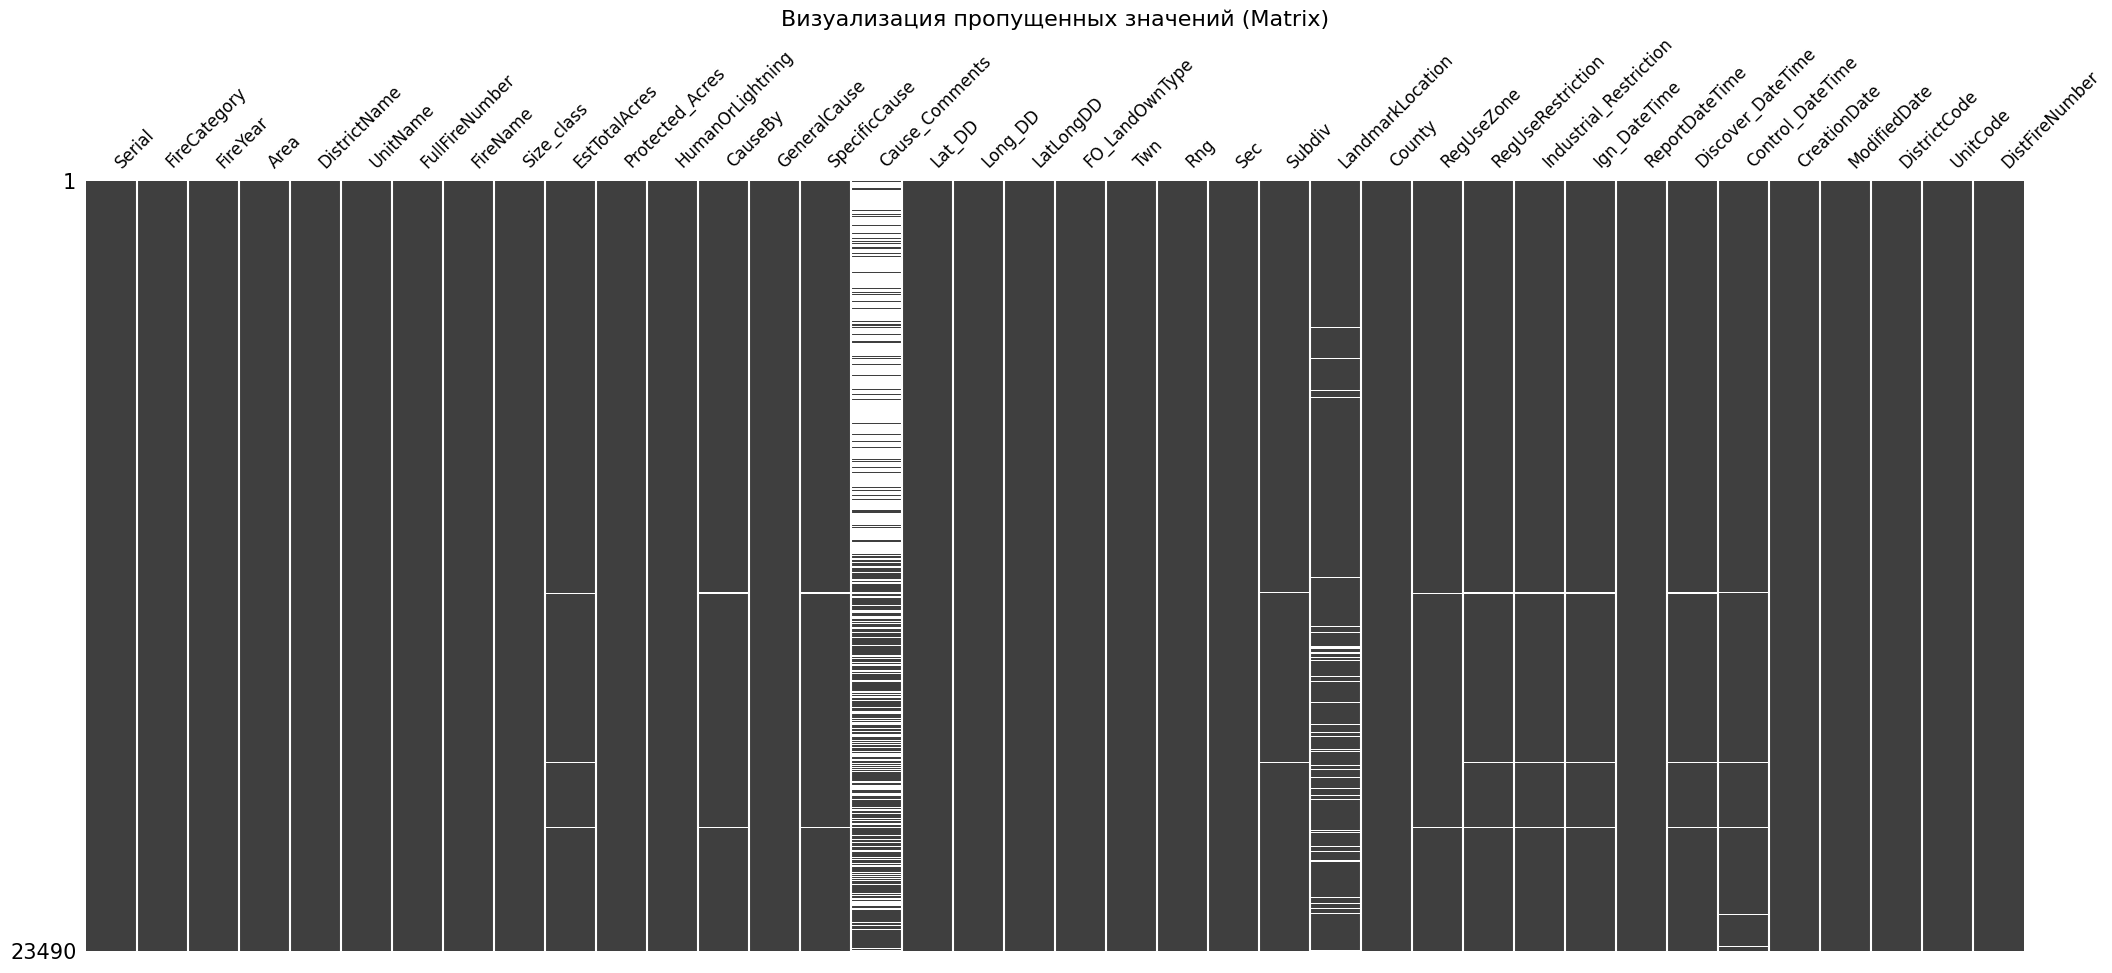

In [ ]:
!pip install missingno

import missingno as msno
import matplotlib.pyplot as plt

# Красивый график пропусков
plt.figure(figsize=(12, 6))
msno.matrix(df, fontsize=12, sparkline=False)
plt.title('Визуализация пропущенных значений (Matrix)', fontsize=16)
plt.show()


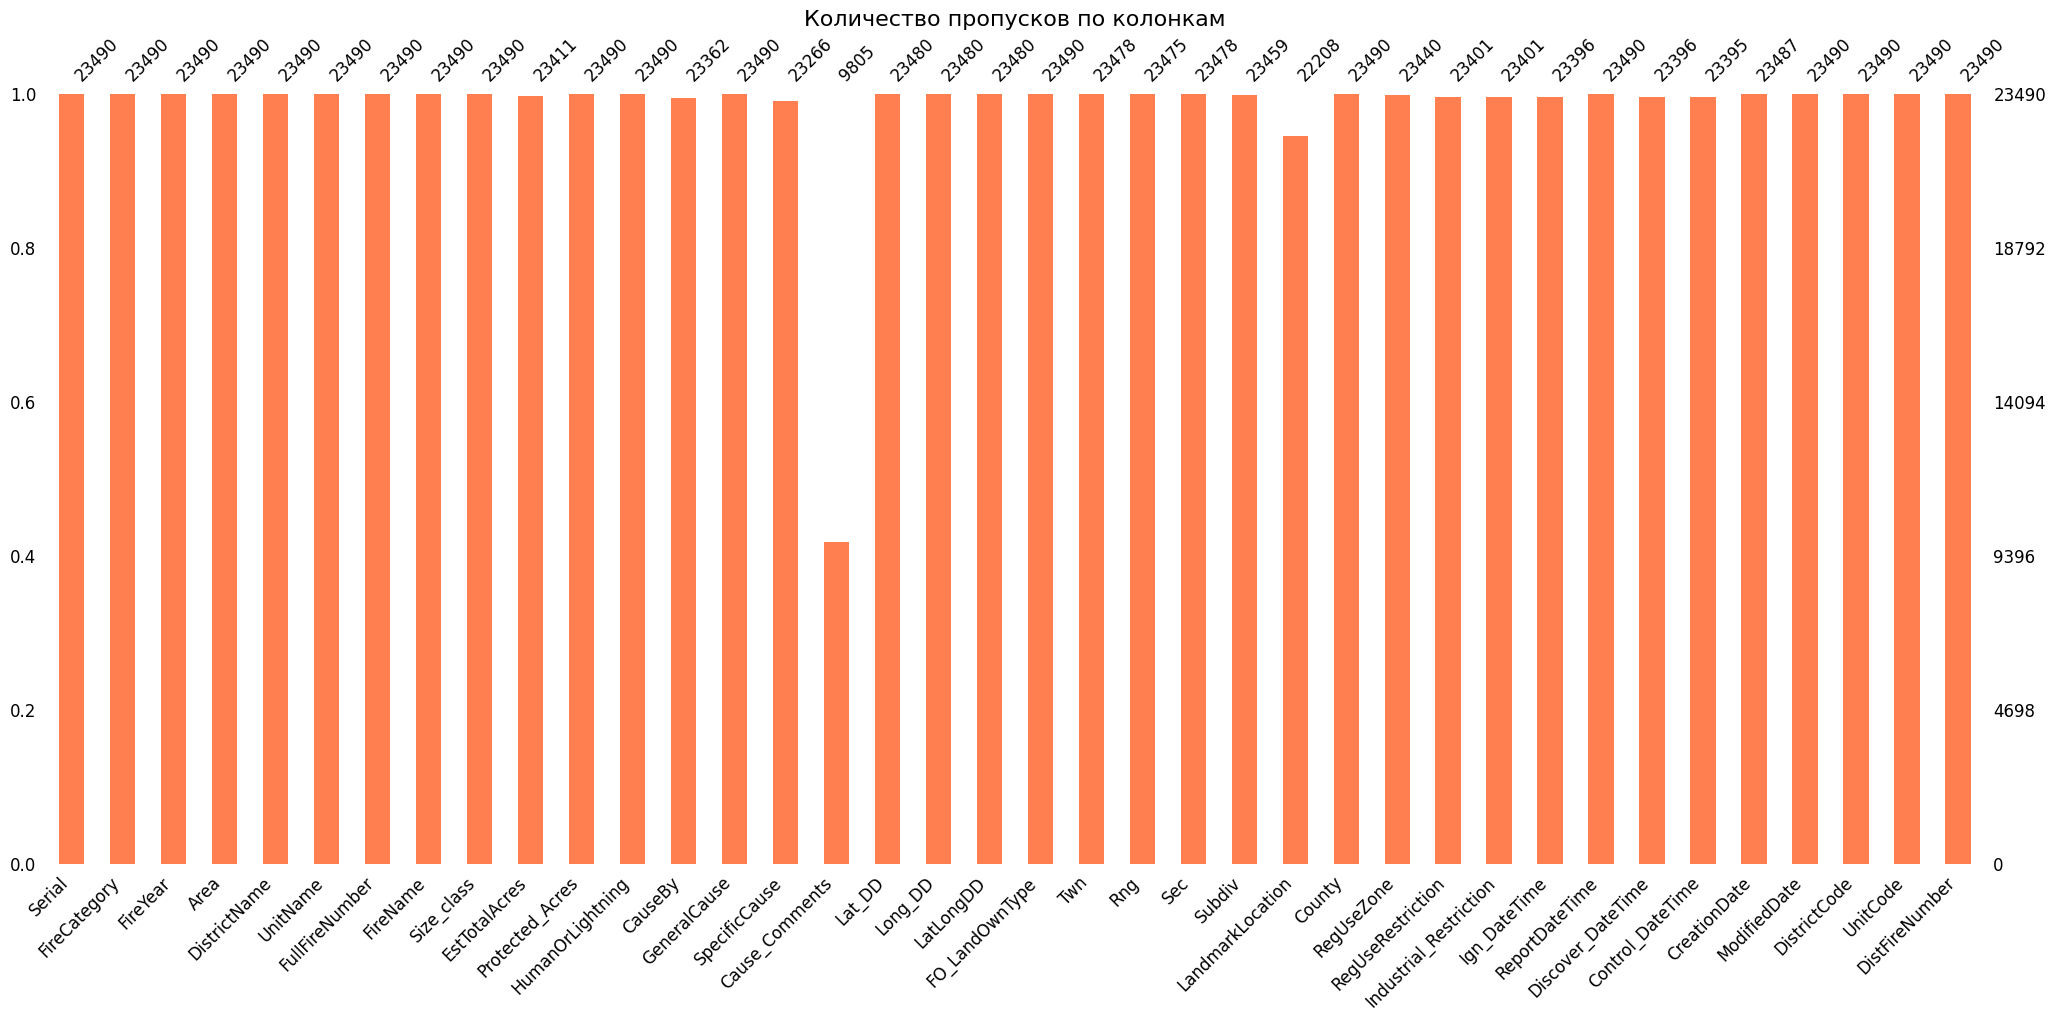

In [ ]:
# Барплот по количеству пропусков
msno.bar(df, color='coral', fontsize=12)
plt.title('Количество пропусков по колонкам', fontsize=16)
plt.show()

In [ ]:
# @title Описание полей {"form-width":"800px"}
import pandas as pd
from IPython.display import display, HTML

# Список с описанием полей
data_description = [
    ("Serial", "уникальный идентификатор записи. Не влияет на пожар."),
    ("FireCategory", "категория пожара (например, 'STAT'). Может указывать на уровень угрозы."),
    ("FireYear", "год возникновения пожара. Полезно для анализа тенденций."),
    ("Area", "регион возникновения пожара, например, 'EOA'."),
    ("DistrictName", "название округа. Полезно для геоанализа."),
    ("UnitName", "название подразделения, отвечающего за тушение."),
    ("FullFireNumber", "уникальный номер пожара. Не даёт полезной информации."),
    ("FireName", "название пожара. Обычно уникально, неинформативно."),
    ("Size_class", "класс размера пожара (A, B, C и т.д.)."),
    ("EstTotalAcres", "оценочная площадь, пройденная пожаром (в акрах)."),
    ("Protected_Acres", "защищённая площадь. Можно сравнивать с общей."),
    ("HumanOrLightning", "причина пожара: человек или молния."),
    ("CauseBy", "детальная причина пожара."),
    ("GeneralCause", "обобщённая причина пожара."),
    ("SpecificCause", "конкретная причина возникновения."),
    ("Cause_Comments", "дополнительные текстовые комментарии."),
    ("Lat_DD", "широта. Географическая привязка."),
    ("Long_DD", "долгота. Географическая привязка."),
    ("LatLongDD", "комбинация широты и долготы."),
    ("FO_LandOwnType", "тип землевладения."),
    ("Twn", "тауншип (часть системы координат в США)."),
    ("Rng", "координата 'range' (аналогично Twn)."),
    ("Sec", "секция земли. Локализация."),
    ("Subdiv", "подразделение секции."),
    ("LandmarkLocation", "описание ориентира поблизости."),
    ("County", "город, где произошёл пожар."),
    ("RegUseZone", "зона регулирования использования."),
    ("RegUseRestriction", "ограничения на использование ресурсов."),
    ("Industrial_Restriction", "промышленные ограничения."),
    ("Ign_DateTime", "дата и время возгорания."),
    ("ReportDateTime", "дата и время сообщения о пожаре."),
    ("Discover_DateTime", "дата и время обнаружения."),
    ("Control_DateTime", "дата и время взятия под контроль."),
    ("CreationDate", "дата создания записи."),
    ("ModifiedDate", "дата последнего обновления записи."),
    ("DistrictCode", "код округа (дубликат DistrictName)."),
    ("UnitCode", "код подразделения (дубликат UnitName)."),
    ("DistFireNumber", "номер пожара в округе."),
]

desc_df = pd.DataFrame(data_description, columns=["Поле", "Описание"])

display(HTML(desc_df.to_html(index=False, escape=False)))

Поле,Описание
Serial,уникальный идентификатор записи. Не влияет на пожар.
FireCategory,"категория пожара (например, 'STAT'). Может указывать на уровень угрозы."
FireYear,год возникновения пожара. Полезно для анализа тенденций.
Area,"регион возникновения пожара, например, 'EOA'."
DistrictName,название округа. Полезно для геоанализа.
UnitName,"название подразделения, отвечающего за тушение."
FullFireNumber,уникальный номер пожара. Не даёт полезной информации.
FireName,"название пожара. Обычно уникально, неинформативно."
Size_class,"класс размера пожара (A, B, C и т.д.)."
EstTotalAcres,"оценочная площадь, пройденная пожаром (в акрах)."


Анализ причин пожара

In [ ]:
# Частотный анализ по GeneralCause
print("Частота по GeneralCause:")
print(df['GeneralCause'].value_counts(dropna=False))

print("\nПроцентное распределение:")
print(df['GeneralCause'].value_counts(normalize=True, dropna=False).apply(lambda x: f"{x:.2%}"))

# Дополнительно: Частота по CauseBy (если интересуют более детализированные причины)
print("\nТоп-20 значений CauseBy:")
print(df['CauseBy'].value_counts().head(20))

Частота по GeneralCause:
GeneralCause
Lightning         6266
Equipment Use     4768
Debris Burning    4466
Recreation        2950
Miscellaneous     2301
Smoking           1047
Arson              846
Juveniles          570
Under Invest       140
Railroad           136
Name: count, dtype: int64

Процентное распределение:
GeneralCause
Lightning         26.68%
Equipment Use     20.30%
Debris Burning    19.01%
Recreation        12.56%
Miscellaneous      9.80%
Smoking            4.46%
Arson              3.60%
Juveniles          2.43%
Under Invest       0.60%
Railroad           0.58%
Name: proportion, dtype: object

Топ-20 значений CauseBy:
CauseBy
Lightning                   6250
Ruralist-Paying             3995
Recreationist               2921
Other-Public                2373
Motorist                    2008
Other-Landowner Related     1391
Public Utility              1285
Rancher-Farmer               908
Timber Harvest Worker        742
Other Forest Mgt. Worker     373
Ruralist-Non-Paying 

В качестве причин будем рассматривать GeneralCause

В GeneralCause всего 10 уникальных причин: посмотрим общую картину распределения всех причин

GeneralCause

1.   Молния 6266
2.   Использование оборудования 4768
3.   Сжигание мусора 4466
4.   Отдых 2950
5.   Разное 2301
6.   Курение 1047
7.   Поджог 846
8.   Несовершеннолетние 570
9.   Недоинвестированные 140
10.  Железная дорога 136

<ipython-input-8-3f7cfebb37d4>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=top_causeby.index, x=top_causeby.values, palette='magma')


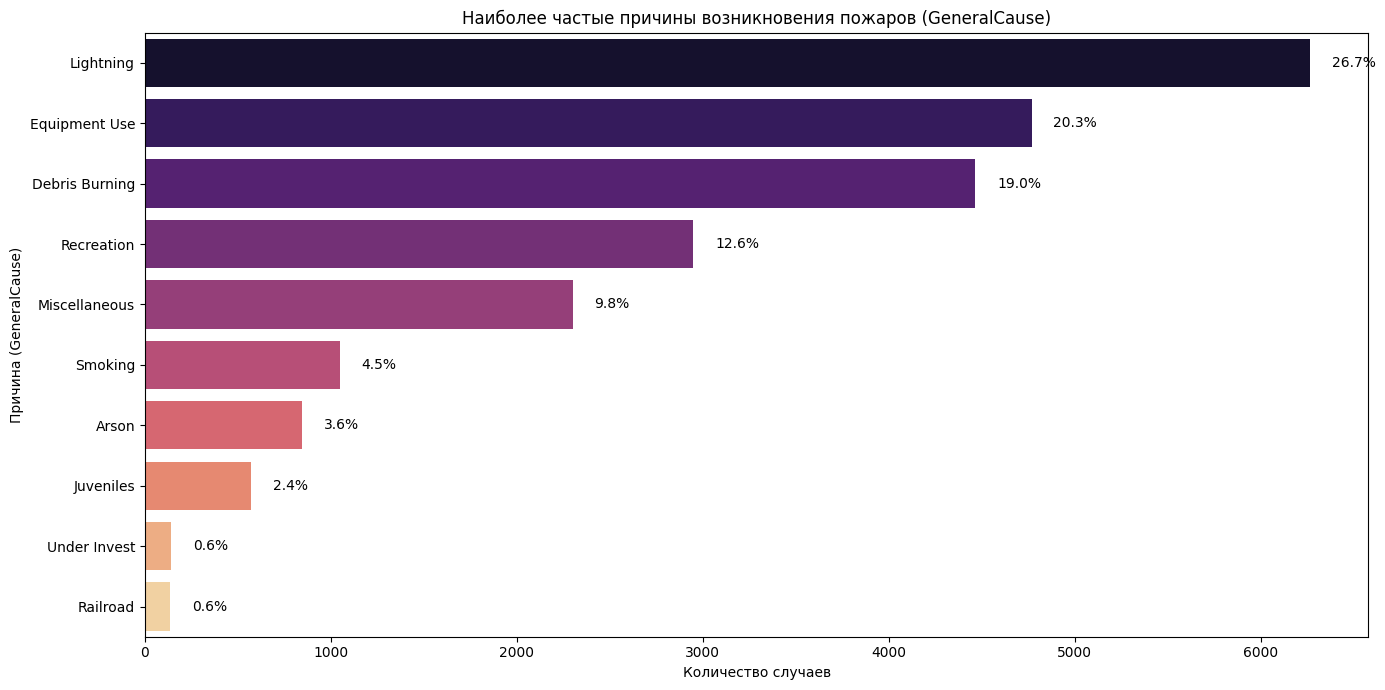

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('forest.csv')  # путь к файлу, если ты запускаешь локально

top_causeby = df['GeneralCause'].value_counts().head(20)
total = df['GeneralCause'].count()

plt.figure(figsize=(14, 7))
ax = sns.barplot(y=top_causeby.index, x=top_causeby.values, palette='magma')

for i, (value, name) in enumerate(zip(top_causeby.values, top_causeby.index)):
    percent = value / total * 100
    ax.text(value + total * 0.005, i, f'{percent:.1f}%', va='center')

plt.title('Наиболее частые причины возникновения пожаров (GeneralCause)')
plt.xlabel('Количество случаев')
plt.ylabel('Причина (GeneralCause)')
plt.tight_layout()
plt.show()


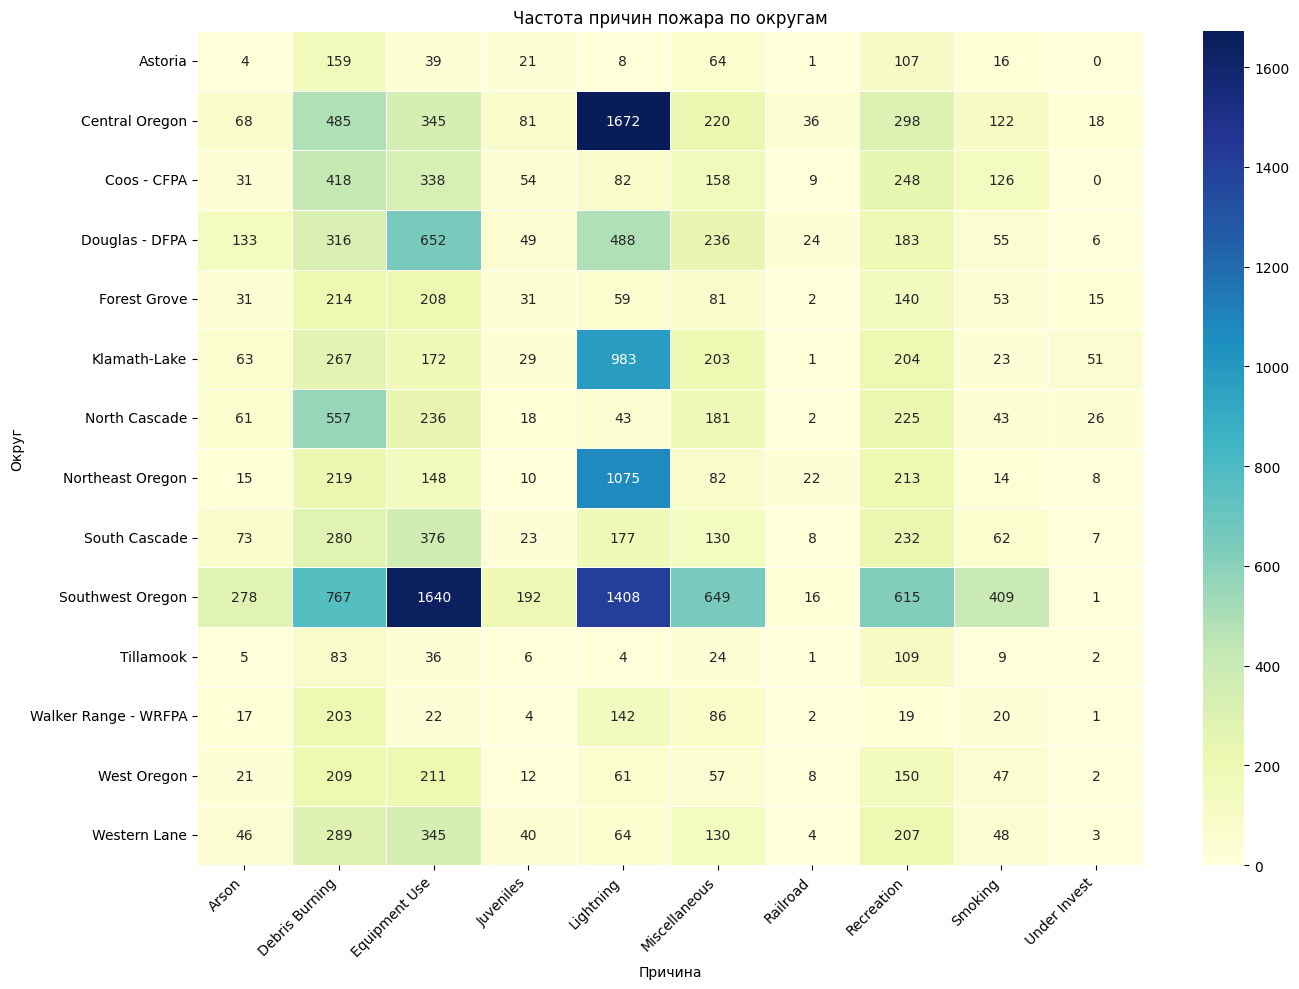

In [ ]:
plt.figure(figsize=(14, 10))
cross_tab = pd.crosstab(df['DistrictName'], df['GeneralCause'])
sns.heatmap(cross_tab, cmap='YlGnBu', annot=True, fmt='d', linewidths=0.5, annot_kws={"size": 10})
plt.title('Частота причин пожара по округам')
plt.xlabel('Причина')
plt.ylabel('Округ')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


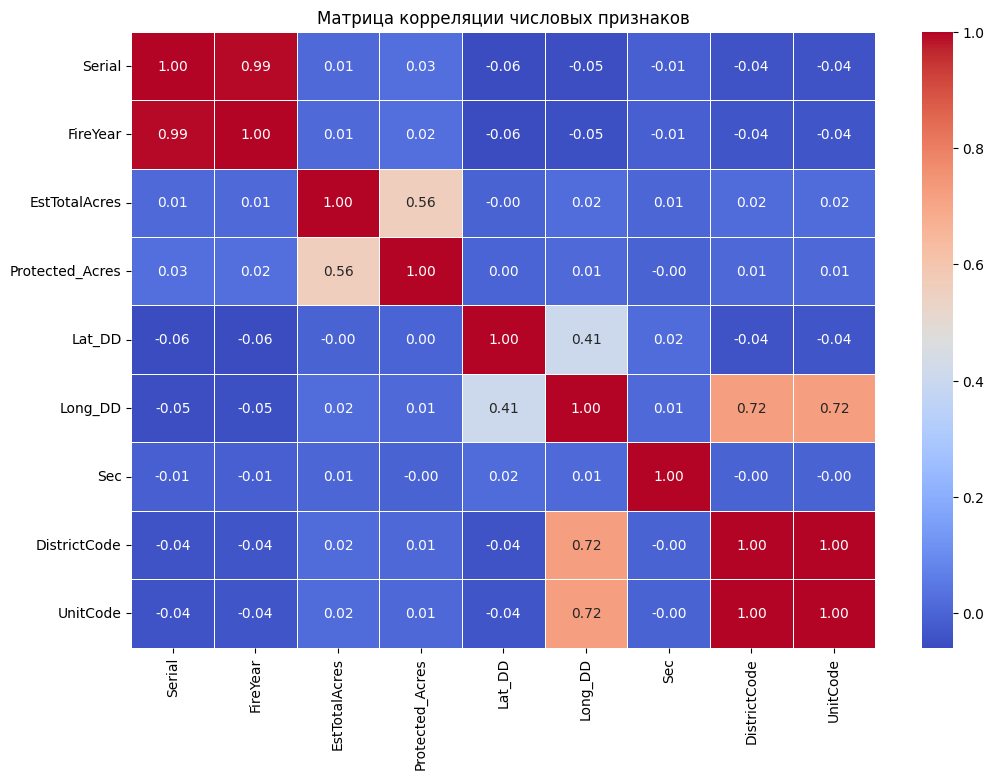

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Матрица корреляции числовых признаков")
plt.show()

Из важных корреляций по этой карте могу выделить только EstTotalAcres и Protected_Acres - умеренная положительная корреляция. Это логично так как проблемные земли нужно сильнее защищать. Остальные взаимосвязи не несут информативности.

Распределение EstTotalAcres показывает, что очень много небольших пожаров до 50 акров, затем их кол-во падает все сильнее к 1000 акров. Потом пожары все реже встречаются. Имеются очень большие пожары свыше 4000 акров, но их очень мало.

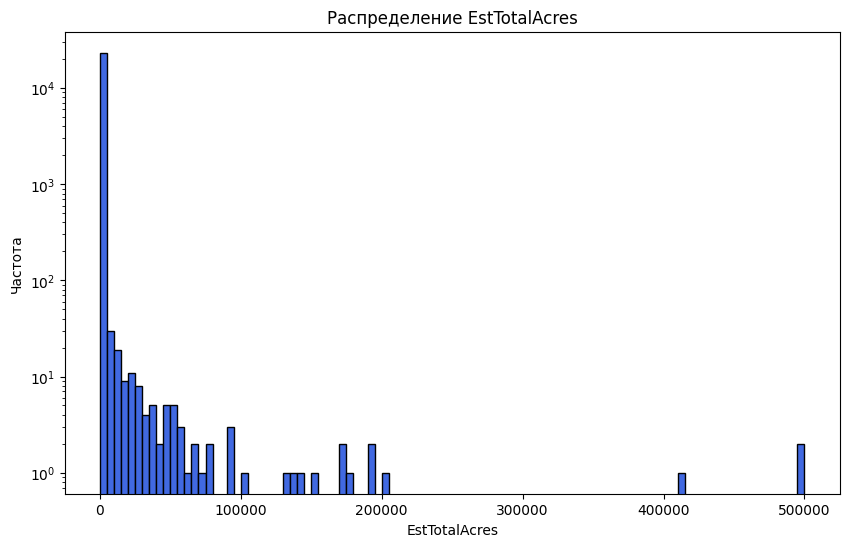

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['EstTotalAcres'].dropna(), bins=100, color='royalblue', edgecolor='black')
plt.title('Распределение EstTotalAcres')
plt.xlabel('EstTotalAcres')
plt.ylabel('Частота')
plt.yscale('log')  # Логарифмическая шкала для лучшей визуализации
plt.show()

**Выбор целевой переменной**

1. EstTotalAcres — оценочная площадь, пройденная пожаром
  
Самый очевидный выбор для регрессионной задачи.
Можно построить модель, предсказывающую размер пожара на основе признаков: региона, причины, времени, типа землевладения и т.д.

Зачем? Чтобы оценивать потенциальный масштаб пожара при его обнаружении

2. Size_class — категориальный класс размера (A, B, C...)

 Хороший вариант для классификации.
Категории часто основаны на диапазоне площадей, например:

A — до 0.25 акра

B — 0.26–9.9

и т.д.

Зачем? Если не хочется предсказывать точное число, а просто "малый", "средний", "большой" пожар.



3. Control_DateTime − Ign_DateTime → Продолжительность пожара

Можно создать целевую переменную "длительность пожара"
(например, в часах/днях — и предсказывать её как регрессию).

Зачем? Чтобы оценить, как долго пожар может длиться.

Возможные, но менее приоритетные цели:
GeneralCause / SpecificCause — можно предсказывать причину, но это не основная цель, обычно это скорее фича.

Protected_Acres — специфичный показатель, полезен в анализе, но не всегда как целевая переменная.

HumanOrLightning — интересная бинарная классификация, но скорее вспомогательная задача.

**Выбираем EstTotalAcres**

1. Средняя площадь пожара по регионам (Area)

In [ ]:
print(df['Area'].unique()) # Проверим какие данные в Area

['EOA' 'SOA' 'NOA']


EOA - восточная

SOA - южная

NOA - северная

В восточной больше всего пожаров: примерно как в южной и северной вместе

<ipython-input-29-a6296ade5923>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_avg.index, y=region_avg.values, palette='viridis')


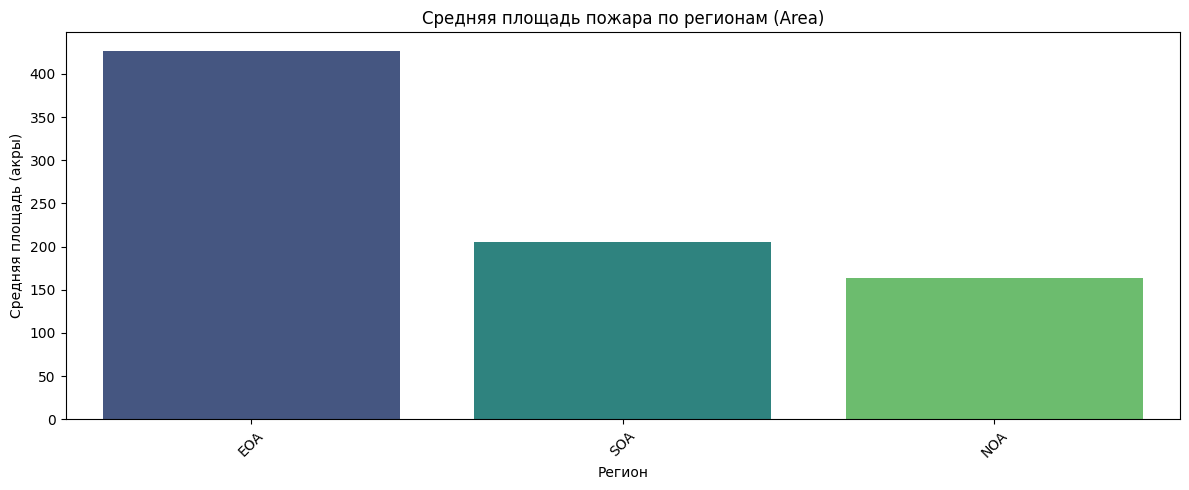

In [ ]:
plt.figure(figsize=(12, 5))
region_avg = df.groupby('Area')['EstTotalAcres'].mean().sort_values(ascending=False)
sns.barplot(x=region_avg.index, y=region_avg.values, palette='viridis')
plt.title('Средняя площадь пожара по регионам (Area)')
plt.ylabel('Средняя площадь (акры)')
plt.xlabel('Регион')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Посмотрим на распределение пожаров по этим 3 группам на карте

In [ ]:
import plotly.express as px

central_oregon = {'lat': 44.058174, 'lon': -121.315308}

fig = px.scatter_mapbox(
    df[df['Area'].isin(['EOA', 'SOA', 'NOA'])],
    lat='Lat_DD',
    lon='Long_DD',
    hover_name="Area",
    color='Area',  # разные цвета для EOA, SOA, NOA
    center=central_oregon,
    mapbox_style='open-street-map',
    width=1000,
    height=1000,
    zoom=5
)

fig.show()


2. EstTotalAcres по обобщённой причине (GeneralCause)

In [ ]:
# Ещё раз посмотрим на GeneralCause
# Кол-во
print(df['GeneralCause'].value_counts(dropna=False))
# В процентах
print(df['GeneralCause'].value_counts(normalize=True, dropna=False) * 100)

GeneralCause
Lightning         6266
Equipment Use     4768
Debris Burning    4466
Recreation        2950
Miscellaneous     2301
Smoking           1047
Arson              846
Juveniles          570
Under Invest       140
Railroad           136
Name: count, dtype: int64
GeneralCause
Lightning         26.675181
Equipment Use     20.297999
Debris Burning    19.012346
Recreation        12.558536
Miscellaneous      9.795658
Smoking            4.457216
Arson              3.601533
Juveniles          2.426564
Under Invest       0.595998
Railroad           0.578970
Name: proportion, dtype: float64


Построим распределение по общим причинам, уберем неинформативные причины

<ipython-input-50-bd86c8fa4c6d>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped.index.astype(str), y=grouped['mean'].values, palette='flare')


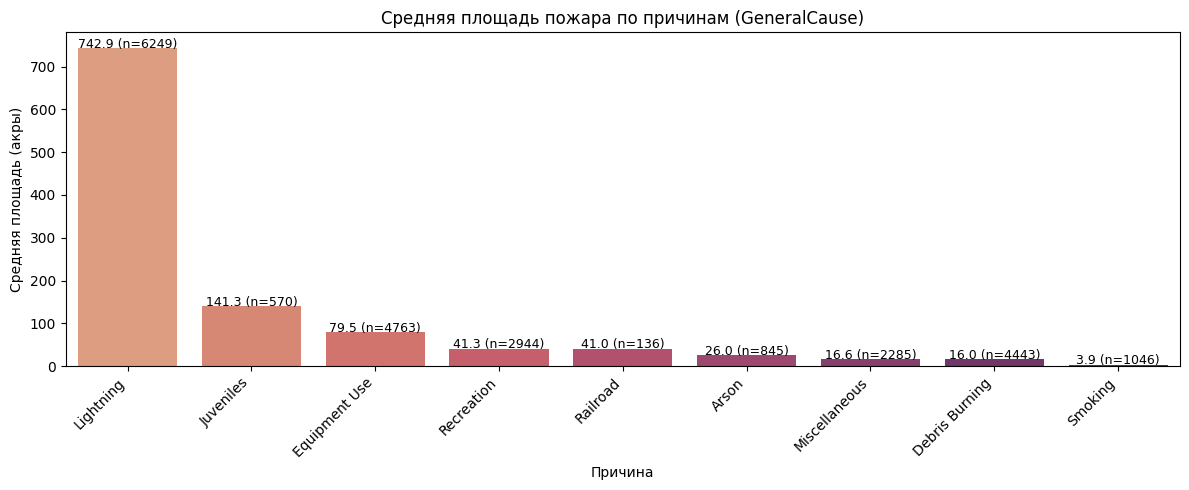

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Опциональная фильтрация: убираем неинформативные причины
excluded_causes = ['Under Invest', 'Unknown', 'Other', 'Undetermined']
filtered_df = df[~df['GeneralCause'].isin(excluded_causes)]

# Группировка: средняя площадь + количество пожаров
grouped = filtered_df.groupby('GeneralCause')['EstTotalAcres'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=grouped.index.astype(str), y=grouped['mean'].values, palette='flare')
plt.title('Средняя площадь пожара по причинам (GeneralCause)')
plt.ylabel('Средняя площадь (акры)')
plt.xlabel('Причина')
plt.xticks(rotation=45, ha='right')

for i, (mean_val, count_val) in enumerate(zip(grouped['mean'].values, grouped['count'].values)):
    plt.text(i, mean_val + 0.5, f'{mean_val:.1f} (n={count_val})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Видим что кол-во случаев с молнией очень велико, а также средняя площадь также очень большая**

На 2 месте Juveniles (несовершеннолетнии)
На 3 GeneralCause (Использование оборудования)

 3. По годам (FireYear)

Посмотрим распределение по годам. Выявим самые пожароопасные года.

<ipython-input-23-a323a075da72>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_avg.index, y=year_avg.values, palette='magma')


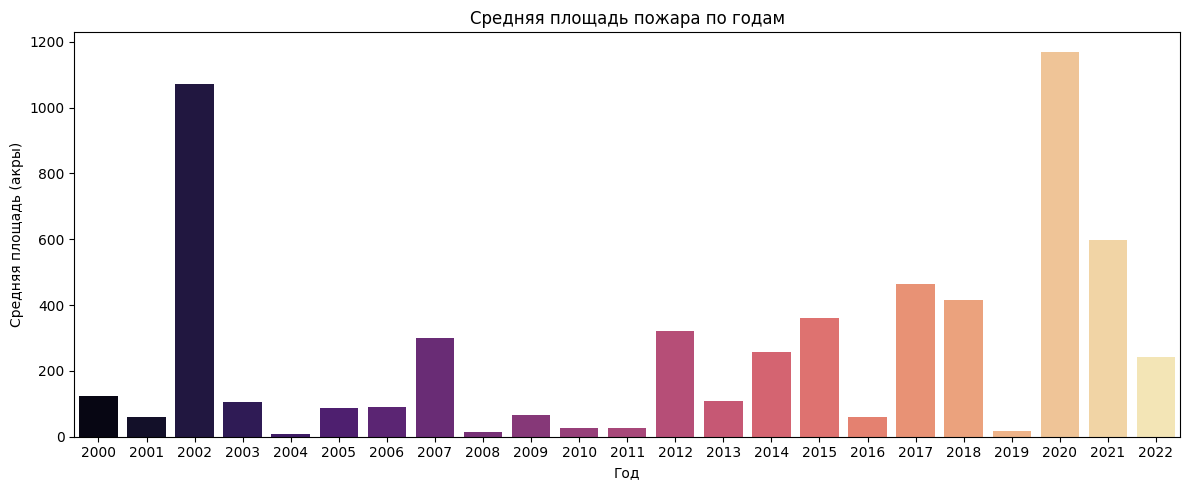

In [ ]:
plt.figure(figsize=(12, 5))
year_avg = df.groupby('FireYear')['EstTotalAcres'].mean()
sns.barplot(x=year_avg.index, y=year_avg.values, palette='magma')
plt.title('Средняя площадь пожара по годам')
plt.xlabel('Год')
plt.ylabel('Средняя площадь (акры)')
plt.tight_layout()
plt.show()


Сильно выделяются 2002 и 2020.

И крупные: 2007, 2012, 2014, 2015, 2017, 2018, 2021, 2022

4. По типу землевладения (FO_LandOwnType)

In [ ]:
# Кол-во
print(df['FO_LandOwnType'].value_counts(dropna=False))
# В процентах
print(df['FO_LandOwnType'].value_counts(normalize=True, dropna=False) * 100)


FO_LandOwnType
Rural Residential    5791
Industrial           4343
Other Private        3849
Small Woodlands      2696
BLM                  2567
State                1842
County               1045
Other Public          404
USFS                  391
Municipal             191
Agriculture           135
Ocean Shores          123
BIA                    98
ERROR: #N/A            14
NPS                     1
Name: count, dtype: int64
FO_LandOwnType
Rural Residential    24.653044
Industrial           18.488719
Other Private        16.385696
Small Woodlands      11.477224
BLM                  10.928054
State                 7.841635
County                4.448702
Other Public          1.719881
USFS                  1.664538
Municipal             0.813112
Agriculture           0.574713
Ocean Shores          0.523627
BIA                   0.417199
ERROR: #N/A           0.059600
NPS                   0.004257
Name: proportion, dtype: float64


<ipython-input-52-8ba0bbb5dea9>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped.index.astype(str), y=grouped['mean'].values, palette='cubehelix')


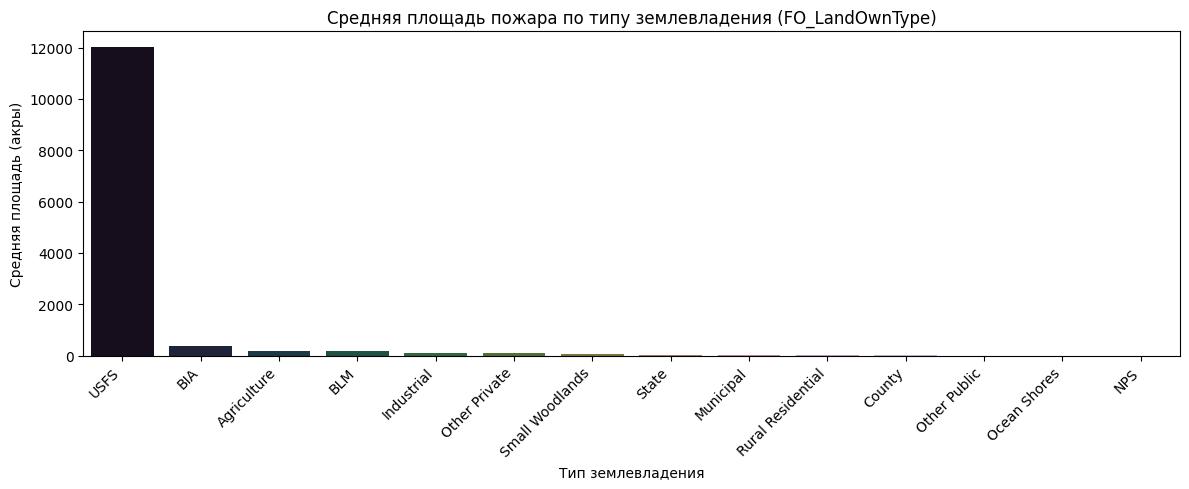

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Исключаем некорректные значения
filtered_df = df[df['FO_LandOwnType'] != 'ERROR: #N/A']

# Группировка: средняя площадь и количество
grouped = filtered_df.groupby('FO_LandOwnType')['EstTotalAcres'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=grouped.index.astype(str), y=grouped['mean'].values, palette='cubehelix')
plt.title('Средняя площадь пожара по типу землевладения (FO_LandOwnType)')
plt.xlabel('Тип землевладения')
plt.ylabel('Средняя площадь (акры)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Высокая средняя площадь пожара для USFS (Служба лесов США) может быть связана с несколькими факторами:

Тип территории: Земли, управляемые USFS, включают большие лесные участки, которые могут быть более подвержены крупным пожарам. Леса занимают большие площади, что может приводить к более крупным и интенсивным пожарам.

Управление лесами: На этих территориях могут происходить естественные или контролируемые лесные пожары, которые охватывают большие площади, особенно в районах с высокой растительностью.

Природные факторы: В районах, управляемых USFS, могут быть специфические климатические условия, такие как сухость, высокие температуры или сильные ветры, которые способствуют распространению пожаров на большие площади.

Статистическая аномалия: Возможно, в данных есть несколько очень крупных пожаров на землях USFS, которые сильно завышают среднюю площадь для этой категории.

В целом, это вполне логично, что земля, управляемая USFS, может иметь более крупные пожары, если на ней расположены обширные лесные массивы.

5. По источнику пожара (HumanOrLightning)

In [ ]:
# Частотное распределение значений
print(df['HumanOrLightning'].value_counts(dropna=False))

HumanOrLightning
Human           17197
Lightning        6266
Under Invest       27
Name: count, dtype: int64


In [ ]:
df['HumanOrLightning'].value_counts()

,count
HumanOrLightning,
Human,17197
Lightning,6266
Under Invest,27


In [ ]:
df.groupby('HumanOrLightning')['EstTotalAcres'].agg(['count', 'mean', 'sum'])


,count,mean,sum
HumanOrLightning,,,
Human,17145,80.079509,1372963.18
Lightning,6249,742.861787,4642143.31
Under Invest,17,19097.112353,324650.91


<ipython-input-49-ef18f5d08fa3>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped.index.astype(str), y=grouped['mean'].values, palette='Set2')


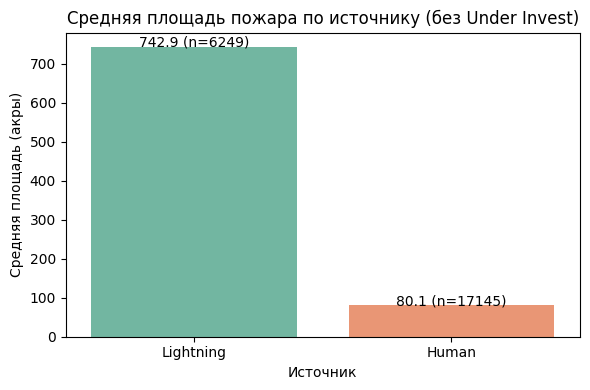

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Фильтрация: убираем "Under Invest"
filtered_df = df[df['HumanOrLightning'] != 'Under Invest']

# Группировка
grouped = filtered_df.groupby('HumanOrLightning')['EstTotalAcres'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=grouped.index.astype(str), y=grouped['mean'].values, palette='Set2')
plt.title('Средняя площадь пожара по источнику (без Under Invest)')
plt.ylabel('Средняя площадь (акры)')
plt.xlabel('Источник')
plt.xticks(rotation=0)

for i, (mean_val, count_val) in enumerate(zip(grouped['mean'].values, grouped['count'].values)):
    plt.text(i, mean_val + 0.5, f'{mean_val:.1f} (n={count_val})', ha='center')

plt.tight_layout()
plt.show()


Кол-во пожаров вызванных молнией меньше в 3 раза, но средняя площадь пожара в 9 раз выше

Средняя площадь пожара по округу

Выявим самые пожароопасные округа

<ipython-input-45-549e05a75fae>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_avg.index.astype(str), y=district_avg.values, palette='mako')


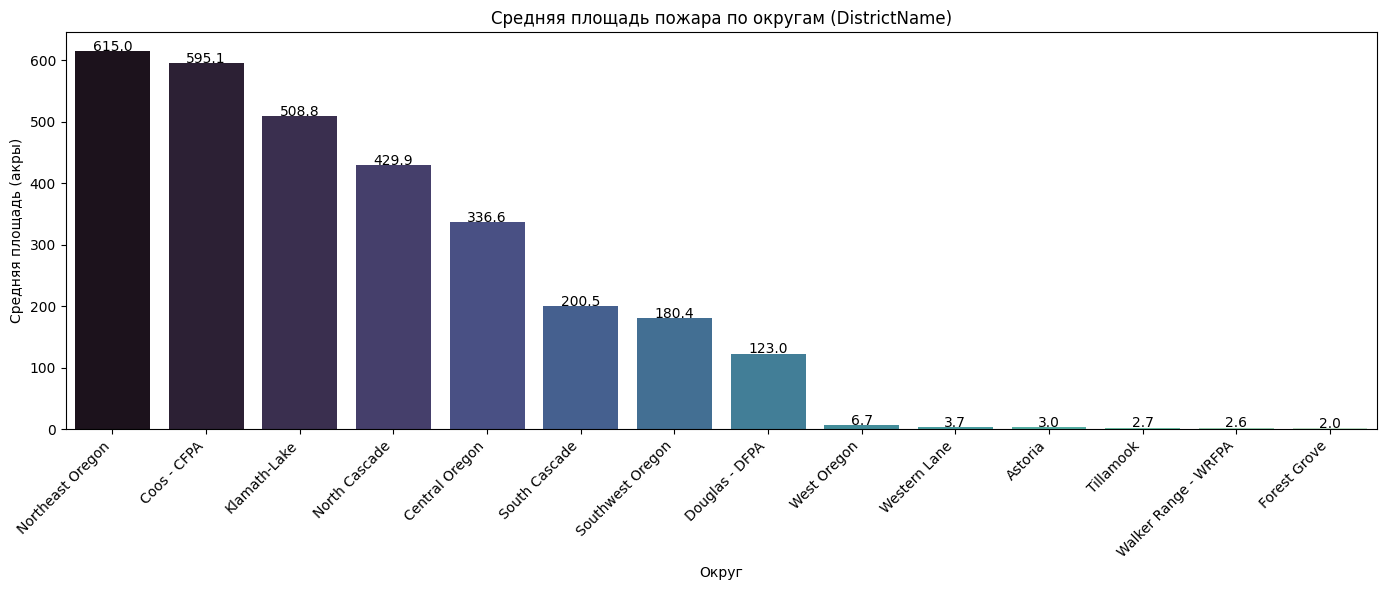

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Группировка: средняя площадь пожара по округу
district_avg = df.groupby('DistrictName')['EstTotalAcres'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=district_avg.index.astype(str), y=district_avg.values, palette='mako')
plt.title('Средняя площадь пожара по округам (DistrictName)')
plt.ylabel('Средняя площадь (акры)')
plt.xlabel('Округ')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(district_avg.values):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()

**Мат статистика**

Проверка гипотез (t-test, ANOVA).

Отличается ли средняя площадь пожара в зависимости от причины (GeneralCause)?

Если p < 0.05, то → есть статистически значимые различия между группами.

In [ ]:
from scipy.stats import f_oneway

grouped = [group['EstTotalAcres'].dropna() for name, group in df.groupby('GeneralCause') if len(group) > 5]
f_stat, p_val = f_oneway(*grouped)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val:.4e}")

ANOVA F-statistic: 21.9688, p-value: 1.4661e-37


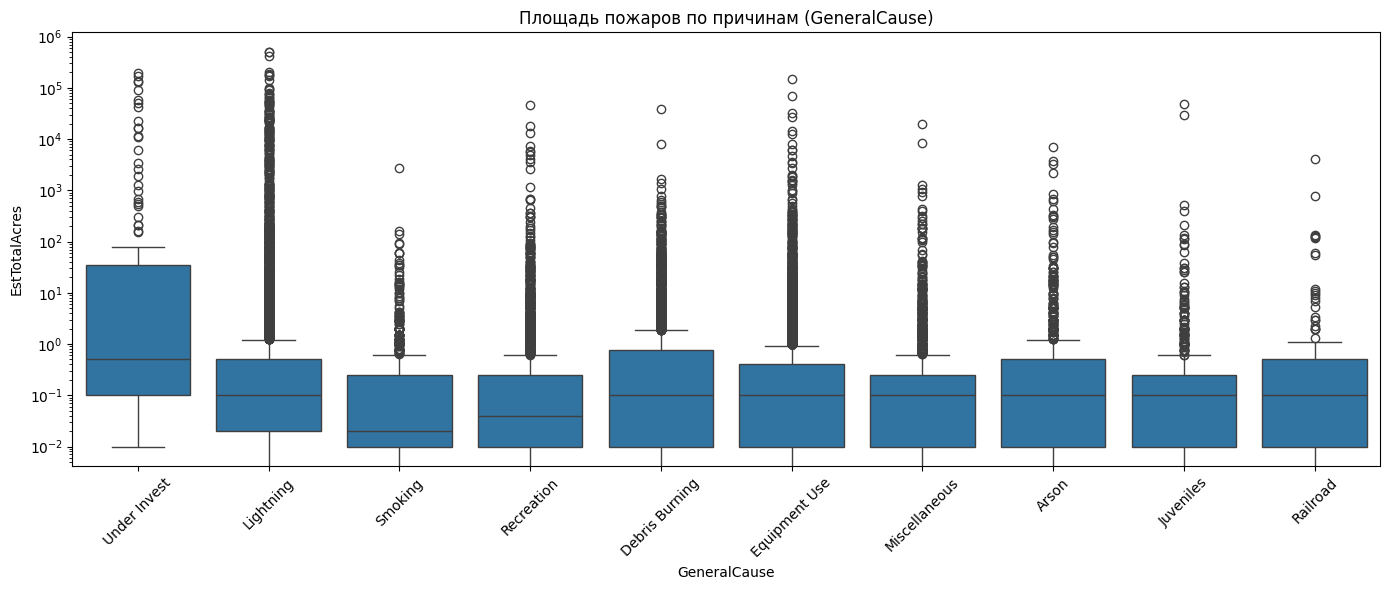

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.boxplot(data=df[df['GeneralCause'].notna() & df['EstTotalAcres'].notna()],
            x='GeneralCause', y='EstTotalAcres')
plt.xticks(rotation=45)
plt.yscale('log')  # если много выбросов и разброс
plt.title('Площадь пожаров по причинам (GeneralCause)')
plt.tight_layout()
plt.show()

Хи-квадрат тест: зависят ли причины пожара от округа

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['DistrictName'], df['GeneralCause'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"χ²: {chi2:.2f}, p-value: {p:.5f}, DoF: {dof}")

χ²: 6337.85, p-value: 0.00000, DoF: 117


χ² = 6337.85 — большая статистика хи-квадрат → сильные различия между ожидаемыми и фактическими значениями.

p-value = 0.00000 — вероятность получить такой результат при верной H₀ практически нулевая.

DoF = 117 — степени свободы (число округов – 1) × (число причин – 1). (13*9)

Вывод:

Причины пожара зависят от округа (DistrictName). Распределение причин не одинаково по регионам, что может быть связано с человеческим фактором, погодными условиями или типами местности.

**Зависит ли площадь пожара от округа ?**

Посмотрим как распределены данные

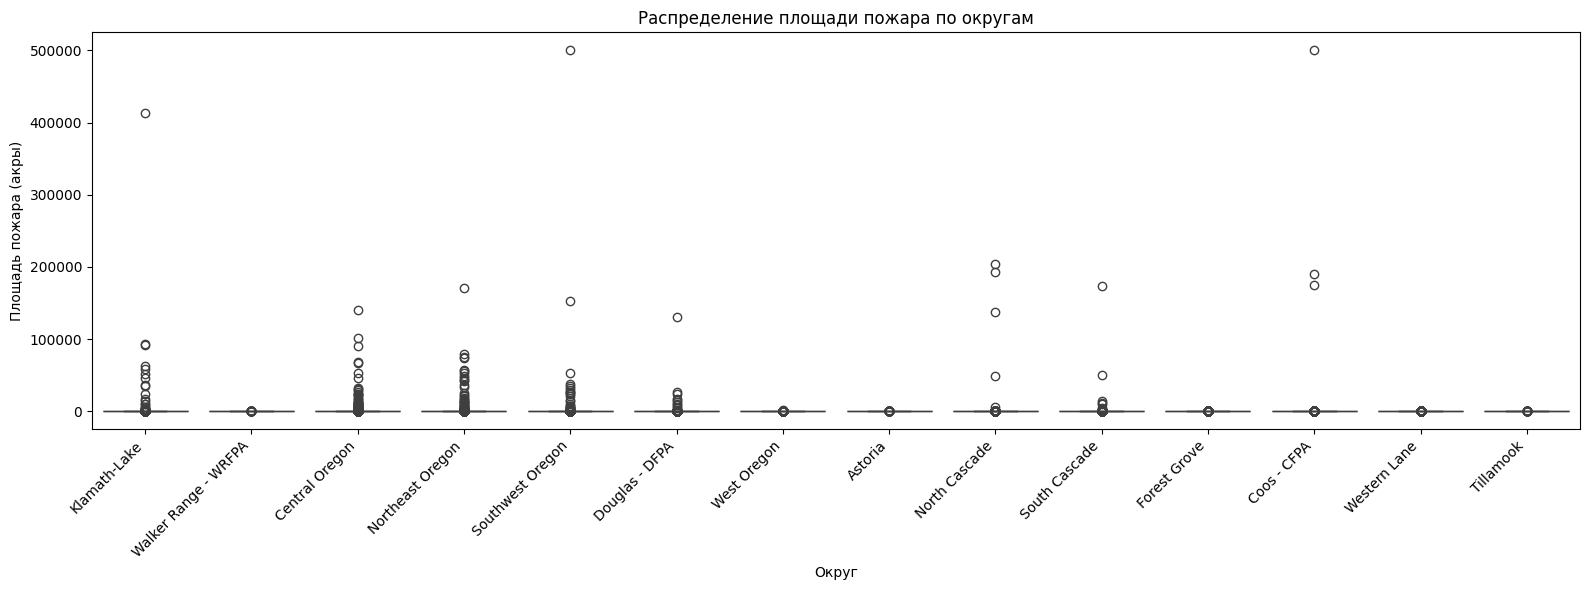

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))
sns.boxplot(x='DistrictName', y='EstTotalAcres', data=df)
plt.title('Распределение площади пожара по округам')
plt.xlabel('Округ')
plt.ylabel('Площадь пожара (акры)')
plt.xticks(rotation=45, ha='right')  # Поворот подписей
plt.tight_layout()
plt.show()


Вывод: данные распределены не нормально, тест ANOVA нельзя применить. Используем непараметрический тест — Kruskal–Wallis:

In [ ]:
from scipy.stats import kruskal

grouped = [group['EstTotalAcres'].dropna() for name, group in df.groupby('DistrictName')]
stat, p = kruskal(*grouped)
print(f"Kruskal–Wallis test: H = {stat:.4f}, p = {p:.4e}")


Kruskal–Wallis test: H = 1189.6311, p = 3.0116e-246


H₀ (нулевая): Распределение площади пожара (EstTotalAcres) одинаково во всех округах (DistrictName).

H₁ (альтернатива): хотя бы в одном округе распределение отличается.

Kruskal–Wallis test: H = 1189.6311, p = 3.0116e-246
Очень высокая H-статистика говорит о больших отличиях между группами.

p-value ≈ 0 — вероятность получить такие данные при условии, что округ не влияет на площадь пожара, стремится к нулю.
Мы уверенно отвергаем H₀.

Вывод: да, площадь пожара статистически значимо зависит от округа. Причём отличия не просто в средних, а в форме распределения, медианах, разбросе и т.д.



Проверка взаимосвязи защищённой площадью и общей площадью пожара

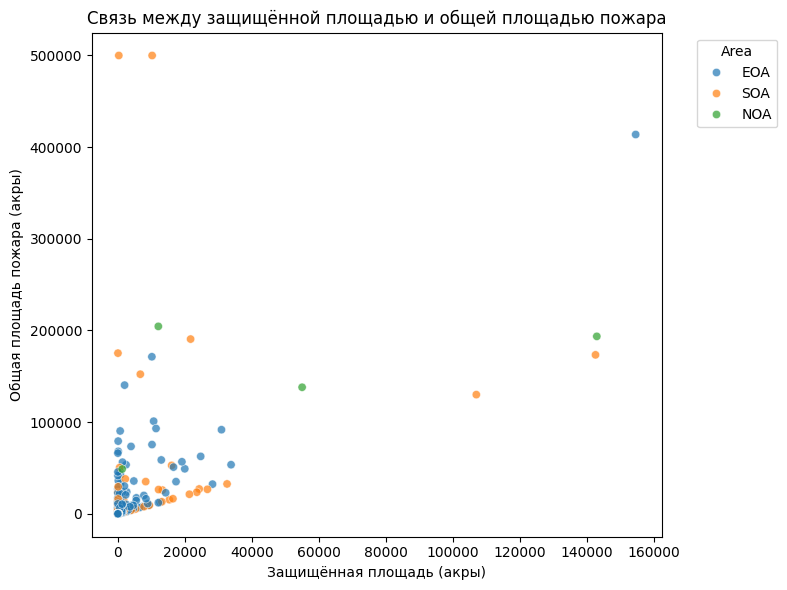

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Protected_Acres', y='EstTotalAcres', data=df, hue='Area', alpha=0.7)
plt.title('Связь между защищённой площадью и общей площадью пожара')
plt.xlabel('Защищённая площадь (акры)')
plt.ylabel('Общая площадь пожара (акры)')
plt.legend(title='Area', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Явная положительная корреляция — чем больше защищённая площадь, тем чаще и больше пожары (хотя связь не линейная, она есть).
Плотное скопление в левом нижнем углу:
Основная масса пожаров происходит на территориях с относительно небольшой защищённой площадью (меньше 20,000 акров).
Это может быть связано с тем, что большинство пожаров происходят в небольших зонах, либо не охватывают сразу большие площади.

Вывод: защищённая площадь не обязательно означает, что пожары меньше — наоборот, они могут быть больше, потому что эти районы более уязвимы или сложны в защите.